# ITT — Tramo Avenida Ciudad de Cali
## Índice de Transformación Territorial · Seguridad & Movilidad · 2023-2025
---
**Dimensiones:** Seguridad (30%) · Movilidad (25%) · Entorno Urbano (20% ref) · Educación y Des. (13% ref) · Cohesión Social (12%)  
**Período:** 2023 – 2025 · 8 tramos buffer 100m


## Celda 1 — Instalación de dependencias


In [1]:
!pip install geopandas pyproj shapely openpyxl matplotlib seaborn -q

import subprocess, sys
def check_pkg(pkg):
    try:
        __import__(pkg)
    except ImportError:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

for p in ['geopandas','pyproj','shapely','openpyxl','seaborn']:
    check_pkg(p)

print('✅ Dependencias verificadas')


✅ Dependencias verificadas


## Celda 2 — Importaciones y configuración visual


In [2]:
import json, os, warnings
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
warnings.filterwarnings('ignore')

# ── Paleta institucional ──────────────────────────────────
C_SEG    = '#1B4F8A'    # azul    - Seguridad
C_MOV    = '#E8852A'    # naranja - Movilidad
C_ITT    = '#2E7D32'    # verde   - ITT Global
C_HOH    = '#5B8DB8'    # azul claro - Homicidios
C_HUR    = '#0D2B6B'    # azul oscuro - Hurtos
C_SIN    = '#F5A742'    # naranja claro - Siniestralidad
C_LES    = '#D95F2B'    # naranja oscuro - Lesionados
C_MOR    = '#8B0000'    # rojo - Mortales
BG       = '#F4F6F9'

NIVEL_COLORS = {
    'Emergencia':     '#E53935',
    'Consolidacion':  '#FB8C00',
    'Avance':         '#43A047',
    'Transformacion': '#1E88E5'
}

plt.rcParams.update({
    'figure.facecolor':  BG,
    'axes.facecolor':    'white',
    'font.family':       'DejaVu Sans',
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         True,
    'grid.alpha':        0.3,
    'axes.titlesize':    11,
    'axes.labelsize':    9,
    'xtick.labelsize':   8,
    'ytick.labelsize':   8,
})

print('✅ Configuración visual lista')


✅ Configuración visual lista


## Celda 3A — Subida de ZIPs  (Colab)


In [3]:
# ─────────────────────────────────────────────────────────────
# CELDA 3A — Subida de ZIPs desde tu computador local (Colab)
#   → Geojson_Ciudad_de_Cali.zip
#   → movilidad.zip
# ─────────────────────────────────────────────────────────────
import zipfile, os
from google.colab import files

print("📂 Selecciona los dos archivos ZIP cuando aparezca el selector...")
print("   → Geojson_Ciudad_de_Cali.zip")
print("   → movilidad.zip")
print()

uploaded = files.upload()   # Abre el selector de archivos

# Descomprimir automáticamente cada ZIP subido
for filename, content in uploaded.items():
    zip_path = f"/content/{filename}"
    with open(zip_path, "wb") as f:
        f.write(content)
    with zipfile.ZipFile(zip_path, "r") as z:
        z.extractall("/content/")
    print(f"✅ Descomprimido: {filename}")
    # Mostrar archivos extraídos
    with zipfile.ZipFile(zip_path, "r") as z:
        for name in z.namelist():
            if name.endswith(".geojson"):
                print(f"   📄 {name}")

print()
print("✅ ZIPs procesados. Ahora ejecuta la Celda 3 para continuar.")


📂 Selecciona los dos archivos ZIP cuando aparezca el selector...
   → Geojson_Ciudad_de_Cali.zip
   → movilidad.zip



Saving Geojson_Ciudad_de_Cali.zip to Geojson_Ciudad_de_Cali.zip
Saving movilidad.zip to movilidad.zip
✅ Descomprimido: Geojson_Ciudad_de_Cali.zip
   📄 Geojson_Ciudad_de_Cali/COMPARENDOS_2023_2025_tramos.geojson
   📄 Geojson_Ciudad_de_Cali/HOMICIDIOS_2023_2025_tramos.geojson
   📄 Geojson_Ciudad_de_Cali/HURTOS_2023_2025_tramos.geojson
   📄 Geojson_Ciudad_de_Cali/VBG_2025_tramos.geojson
   📄 Geojson_Ciudad_de_Cali/VIOLENCIA_INTRAFAMILIAR_2023_2025_tramos.geojson
   📄 Geojson_Ciudad_de_Cali/ciudad_de_Cali_100m.geojson
✅ Descomprimido: movilidad.zip
   📄 movilidad/BD_COMPARENDOS_2025_COMUNA_BARRIO_tramos.geojson
   📄 movilidad/BD_SINIESTROS_2023_2025_tramos.geojson

✅ ZIPs procesados. Ahora ejecuta la Celda 3 para continuar.


## Celda 3 — Rutas y parámetros


In [4]:
import os

BASE_SEG = "/content/Geojson_Ciudad_de_Cali/"
BASE_MOV = "/content/movilidad/"
# BASE_SEG = "./Geojson_Ciudad_de_Cali/"
# BASE_MOV = "./movilidad/"

PATHS = {
    "tramos":      BASE_SEG + "ciudad_de_Cali_100m.geojson",
    "hurtos":      BASE_SEG + "HURTOS_2023_2025_tramos.geojson",
    "homicidios":  BASE_SEG + "HOMICIDIOS_2023_2025_tramos.geojson",
    "siniestros":  BASE_MOV + "BD_SINIESTROS_2023_2025_tramos.geojson",
    "vif":         BASE_SEG + "VIOLENCIA_INTRAFAMILIAR_2023_2025_tramos.geojson",
    "comparendos": BASE_SEG + "COMPARENDOS_2023_2025_tramos.geojson",
}

ANIOS = [2023, 2024, 2025]

# ── Pesos oficiales 5 dimensiones ─────────
PESOS = {
    "Seguridad": 0.30,
    "Movilidad": 0.25,
    "EntornoU":  0.20,
    "EducDes":   0.13,
    "Cohesion":  0.12,
}

# ── Scores referentes Pulmón de Oriente ─────────────────────
# Provisionales — reemplazar cuando haya datos reales del corredor
REF_ENTORNO_U = 39.2
REF_EDUC_DES  = 54.9

CRS_LOCAL = "EPSG:3115"
CRS_GEO   = "EPSG:4326"

ok = True
for nombre, ruta in PATHS.items():
    existe = os.path.exists(ruta)
    print(f"  {chr(9989) if existe else chr(10060)}  {nombre}: {ruta}")
    if not existe: ok = False
print()
if ok: print("Todos los archivos encontrados.")
else:  print("Faltan archivos. Verifica el ZIP en Celda 3A.")
print(f"Periodo: {ANIOS[0]}-{ANIOS[-1]}")
print(f"Pesos: Seg={PESOS['Seguridad']:.0%} Mov={PESOS['Movilidad']:.0%} EntU={PESOS['EntornoU']:.0%} EyD={PESOS['EducDes']:.0%} Coh={PESOS['Cohesion']:.0%}")
print(f"Ref Entorno Urbano={REF_ENTORNO_U}  Ref EducDes={REF_EDUC_DES} (Pulmon de Oriente)")


  ✅  tramos: /content/Geojson_Ciudad_de_Cali/ciudad_de_Cali_100m.geojson
  ✅  hurtos: /content/Geojson_Ciudad_de_Cali/HURTOS_2023_2025_tramos.geojson
  ✅  homicidios: /content/Geojson_Ciudad_de_Cali/HOMICIDIOS_2023_2025_tramos.geojson
  ✅  siniestros: /content/movilidad/BD_SINIESTROS_2023_2025_tramos.geojson
  ✅  vif: /content/Geojson_Ciudad_de_Cali/VIOLENCIA_INTRAFAMILIAR_2023_2025_tramos.geojson
  ✅  comparendos: /content/Geojson_Ciudad_de_Cali/COMPARENDOS_2023_2025_tramos.geojson

Todos los archivos encontrados.
Periodo: 2023-2025
Pesos: Seg=30% Mov=25% EntU=20% EyD=13% Coh=12%
Ref Entorno Urbano=39.2  Ref EducDes=54.9 (Pulmon de Oriente)


## Celda 4 — Carga de datos GeoJSON


In [5]:
def load_gj(path):
    with open(path, encoding='utf-8') as f:
        return json.load(f)

# Tramos del corredor (8 polígonos buffer 100m) — CRS: EPSG:3115
gdf_tramos = gpd.GeoDataFrame.from_features(
    load_gj(PATHS['tramos'])['features'], crs=CRS_LOCAL
)
gdf_tramos['tramo'] = gdf_tramos['tramo'].astype(int)
gdf_tramos = gdf_tramos[['tramo','distancia','geometry']].sort_values('tramo').reset_index(drop=True)

# Datos brutos
raw_hurtos     = load_gj(PATHS['hurtos'])
raw_homicidios = load_gj(PATHS['homicidios'])
raw_siniestros = load_gj(PATHS['siniestros'])

print(f'✅ Tramos cargados:     {len(gdf_tramos)} polígonos')
print(f'   Hurtos (features):  {len(raw_hurtos["features"])}')
print(f'   Homicidios total:   {len(raw_homicidios["features"])}')
print(f'   Siniestros total:   {len(raw_siniestros["features"])}')
print()
print(gdf_tramos[['tramo','distancia']].rename(columns={'distancia':'longitud_m'}).to_string(index=False))


✅ Tramos cargados:     8 polígonos
   Hurtos (features):  3175
   Homicidios total:   153
   Siniestros total:   745

 tramo  longitud_m
     1 1051.292999
     2 1860.792027
     3 2317.381394
     4 3193.353676
     5 2230.289177
     6 1842.259725
     7 4523.784952
     8 1880.926573


## Celda 5 — Procesamiento espacial: Homicidios


In [6]:
# Homicidios — coordenadas WGS84, reproyectar a EPSG:3115
df_hom_raw = pd.DataFrame([f['properties'] for f in raw_homicidios['features']])
df_hom_raw['FECHA_HECH'] = pd.to_datetime(df_hom_raw['FECHA_HECH'])
df_hom_raw['año']        = df_hom_raw['FECHA_HECH'].dt.year
df_hom_raw['trimestre']  = df_hom_raw['FECHA_HECH'].dt.quarter
df_hom_raw['_uid']       = range(len(df_hom_raw))
df_hom_raw = df_hom_raw[df_hom_raw['año'].isin(ANIOS)].copy()

gdf_hom = gpd.GeoDataFrame(
    df_hom_raw,
    geometry=gpd.points_from_xy(df_hom_raw['X'], df_hom_raw['Y']),
    crs=CRS_GEO
).to_crs(CRS_LOCAL)

hom_join = gpd.sjoin(
    gdf_hom, gdf_tramos[['tramo','geometry']], how='left', predicate='within'
).drop_duplicates(subset='_uid')  # evita doble conteo en bordes

# Agregaciones
hom_trim  = hom_join.groupby(['tramo','año','trimestre']).size().reset_index(name='homicidios')
hom_anual = hom_join.groupby(['tramo','año']).size().reset_index(name='homicidios')

print(f'✅ Homicidios procesados: {len(df_hom_raw)} registros filtrados 2023-2024')
print(f'   Asignados a tramo:    {hom_join["tramo"].notna().sum()}')
print()
pivot = hom_anual.pivot(index='tramo', columns='año', values='homicidios').fillna(0).astype(int)
pivot['TOTAL'] = pivot.sum(axis=1)
print(pivot.to_string())


✅ Homicidios procesados: 153 registros filtrados 2023-2024
   Asignados a tramo:    144

año    2023  2024  2025  TOTAL
tramo                         
1.0       1     0     1      2
2.0       2     1     1      4
3.0       8     6     7     21
4.0      17    13    16     46
5.0      15     9    18     42
6.0      12     5     5     22
7.0       0     4     2      6
8.0       0     0     1      1


## Celda 6 — Procesamiento espacial: Hurtos


In [7]:
# ─────────────────────────────────────────────────────────────────
# CELDA 6 — Procesamiento HURTOS
# Detección automática: si el archivo tiene fecha individual
# lo procesa igual que homicidios (trimestral + anual).
# Si solo tiene totales agregados, usa el acumulado por tramo.
# ─────────────────────────────────────────────────────────────────

df_hur_raw = pd.DataFrame([f["properties"] for f in raw_hurtos["features"]])

# ── Detectar si tiene campo de fecha ─────────────────────────────
CAMPOS_FECHA = ["FECHA_HECH","fecha_hech","FECHA","fecha","Fecha","DATE","date"]
CAMPOS_X    = ["X","x","lon","LON","longitude","LONGITUDE"]
CAMPOS_Y    = ["Y","y","lat","LAT","latitude","LATITUDE"]

campo_fecha = next((c for c in CAMPOS_FECHA if c in df_hur_raw.columns), None)
campo_x     = next((c for c in CAMPOS_X     if c in df_hur_raw.columns), None)
campo_y     = next((c for c in CAMPOS_Y     if c in df_hur_raw.columns), None)

HURTOS_CON_FECHA = campo_fecha is not None

if HURTOS_CON_FECHA:
    print(f"✅ Hurtos con fecha detectada en columna: [{campo_fecha}]")
    print(f"   Coordenadas: x=[{campo_x}]  y=[{campo_y}]")

    df_hur_raw["FECHA"]     = pd.to_datetime(df_hur_raw[campo_fecha])
    df_hur_raw["año"]       = df_hur_raw["FECHA"].dt.year
    df_hur_raw["trimestre"] = df_hur_raw["FECHA"].dt.quarter
    df_hur_raw["_uid"]      = range(len(df_hur_raw))
    df_hur_raw = df_hur_raw[df_hur_raw["año"].isin(ANIOS)].copy()

    gdf_hur = gpd.GeoDataFrame(
        df_hur_raw,
        geometry=gpd.points_from_xy(df_hur_raw[campo_x], df_hur_raw[campo_y]),
        crs=CRS_GEO
    ).to_crs(CRS_LOCAL)

    hur_join = gpd.sjoin(
        gdf_hur, gdf_tramos[["tramo","geometry"]], how="left", predicate="within"
    ).drop_duplicates(subset="_uid")

    # Agregaciones trimestral y anual
    hur_trim  = hur_join.groupby(["tramo","año","trimestre"]).size().reset_index(name="hurtos")
    hur_anual = hur_join.groupby(["tramo","año"]).size().reset_index(name="hurtos")
    hur_total = None   # no se usa en modo con fecha

    print(f"   Registros 2023-2024: {len(df_hur_raw)}")
    print(f"   Asignados a tramo:   {hur_join['tramo'].notna().sum()}")
    print()
    pivot = hur_anual.pivot(index="tramo", columns="año", values="hurtos").fillna(0).astype(int)
    pivot["TOTAL"] = pivot.sum(axis=1)
    print(pivot.to_string())

else:
    print("⚠️  Hurtos sin fecha — solo totales agregados disponibles")
    print(f"   Coordenadas usadas: x=[{campo_x}]  y=[{campo_y}]")

    gdf_hur = gpd.GeoDataFrame(
        df_hur_raw,
        geometry=gpd.points_from_xy(df_hur_raw[campo_x], df_hur_raw[campo_y]),
        crs=CRS_GEO
    ).to_crs(CRS_LOCAL)

    hur_join = gpd.sjoin(
        gdf_hur, gdf_tramos[["tramo","geometry"]], how="left", predicate="within"
    )

    hur_total = (
        hur_join.groupby("tramo")
        .agg(hurtos=("total_hurt","sum"))
        .reset_index()
    )
    hur_trim  = None
    hur_anual = None

    print()
    print(hur_total.to_string(index=False))


✅ Hurtos con fecha detectada en columna: [FECHA_HECH]
   Coordenadas: x=[X]  y=[Y]
   Registros 2023-2024: 3175
   Asignados a tramo:   3074

año    2023  2024  2025  TOTAL
tramo                         
1.0      75    50    44    169
2.0      82    75    64    221
3.0     144   142   188    474
4.0     238   228   181    647
5.0     231   227   179    637
6.0     141   119   131    391
7.0     182   158   177    517
8.0       6     5     7     18


## Celda 7 — Procesamiento espacial: Siniestros (Movilidad)


In [8]:
# Siniestros — coordenadas en EPSG:3115 (misma que tramos, no requiere reproyeccion)
df_sin_raw = pd.DataFrame([f["properties"] for f in load_gj(PATHS["siniestros"])["features"]])
df_sin_raw["Fecha"]     = pd.to_datetime(df_sin_raw["Fecha"])
df_sin_raw["año"]       = df_sin_raw["Año"].astype(int)
df_sin_raw["trimestre"] = df_sin_raw["Fecha"].dt.quarter
df_sin_raw["_uid"]      = range(len(df_sin_raw))
df_sin_raw = df_sin_raw[df_sin_raw["año"].isin(ANIOS)].copy()

gdf_sin = gpd.GeoDataFrame(
    df_sin_raw,
    geometry=gpd.points_from_xy(df_sin_raw["X"], df_sin_raw["Y"]),
    crs=CRS_LOCAL
)

sin_join = gpd.sjoin(
    gdf_sin, gdf_tramos[["tramo","geometry"]], how="left", predicate="within"
).drop_duplicates(subset="_uid")

def agg_sin(df, grp):
    return (
        df.groupby(grp)
        .agg(
            siniestralidad=("_uid",       "count"),
            lesionados    =("Tipo_Confi", lambda x: (x=="Lesiones").sum()),
            mortales      =("Tipo_Confi", lambda x: (x=="Mortal").sum())
        ).reset_index()
    )

sin_trim  = agg_sin(sin_join.dropna(subset=["tramo"]), ["tramo","año","trimestre"])
sin_anual = agg_sin(sin_join.dropna(subset=["tramo"]), ["tramo","año"])

print(f"Siniestros procesados: {len(df_sin_raw)} registros {ANIOS[0]}-{ANIOS[-1]}")
print(f"Asignados a tramo:     {sin_join['tramo'].notna().sum()}")
print()
pivot_sin = sin_anual.pivot(index="tramo", columns="año", values="siniestralidad").fillna(0).astype(int)
pivot_sin["TOTAL"] = pivot_sin.sum(axis=1)
print(pivot_sin.to_string())


Siniestros procesados: 745 registros 2023-2025
Asignados a tramo:     740

año    2023  2024  2025  TOTAL
tramo                         
1.0      32    20    16     68
2.0      28    33    19     80
3.0      56    48    38    142
4.0      63    44    61    168
5.0      35    34    31    100
6.0      37    22    26     85
7.0      34    30    33     97


## Celda 7B — Procesamiento espacial: Cohesión Social (VIF + Riñas)


In [9]:
# CELDA 7B — Cohesion Social: VIF + Rinas (trimestral)

# ── VIF ──────────────────────────────────────────────────────
df_vif = pd.DataFrame([f["properties"] for f in load_gj(PATHS["vif"])["features"]])
df_vif["FECHA_HECH"] = pd.to_datetime(df_vif["FECHA_HECH"])
df_vif["año"]        = df_vif["FECHA_HECH"].dt.year
df_vif["trimestre"]  = df_vif["FECHA_HECH"].dt.quarter
df_vif["_uid"]       = range(len(df_vif))
df_vif = df_vif[df_vif["año"].isin(ANIOS)].copy()

gdf_vif  = gpd.GeoDataFrame(df_vif,
    geometry=gpd.points_from_xy(df_vif["X"], df_vif["Y"]), crs=CRS_GEO).to_crs(CRS_LOCAL)
vif_join = gpd.sjoin(gdf_vif, gdf_tramos[["tramo","geometry"]], how="left", predicate="within").drop_duplicates(subset="_uid")
vif_trim  = vif_join.dropna(subset=["tramo"]).groupby(["tramo","año","trimestre"]).size().reset_index(name="vif")
vif_anual = vif_join.dropna(subset=["tramo"]).groupby(["tramo","año"]).size().reset_index(name="vif")

# ── Riñas ────────────────────────────────────────────────────
df_comp  = pd.DataFrame([f["properties"] for f in load_gj(PATHS["comparendos"])["features"]])
df_rin   = df_comp[df_comp["agrupado"]=="RIÑAS"].copy()
df_rin["fecha_hech"] = pd.to_datetime(df_rin["fecha_hech"])
df_rin["año"]        = df_rin["fecha_hech"].dt.year
df_rin["trimestre"]  = df_rin["fecha_hech"].dt.quarter
df_rin["_uid"]       = range(len(df_rin))
df_rin = df_rin[df_rin["año"].isin(ANIOS)].copy()

gdf_rin  = gpd.GeoDataFrame(df_rin,
    geometry=gpd.points_from_xy(df_rin["lon"], df_rin["lat"]), crs=CRS_GEO).to_crs(CRS_LOCAL)
rin_join = gpd.sjoin(gdf_rin, gdf_tramos[["tramo","geometry"]], how="left", predicate="within").drop_duplicates(subset="_uid")
rin_trim  = rin_join.dropna(subset=["tramo"]).groupby(["tramo","año","trimestre"]).size().reset_index(name="rinas")
rin_anual = rin_join.dropna(subset=["tramo"]).groupby(["tramo","año"]).size().reset_index(name="rinas")

print(f"VIF   — registros: {len(df_vif)} | asignados: {vif_join['tramo'].notna().sum()}")
print(f"Rinas — registros: {len(df_rin)} | asignados: {rin_join['tramo'].notna().sum()}")
print()
print("VIF por año:")
print(vif_anual.pivot(index="tramo",columns="año",values="vif").fillna(0).astype(int).to_string())
print()
print("Rinas por año:")
print(rin_anual.pivot(index="tramo",columns="año",values="rinas").fillna(0).astype(int).to_string())


VIF   — registros: 769 | asignados: 718
Rinas — registros: 841 | asignados: 829

VIF por año:
año    2023  2024  2025
tramo                  
1.0      15    13    10
2.0      15    11    12
3.0      36    31    31
4.0      42    48    65
5.0      78    84    92
6.0      28    28    31
7.0      14    16    15
8.0       0     2     1

Rinas por año:
año    2023  2024  2025
tramo                  
1.0       6     2    20
2.0      20     7    10
3.0       9    27    37
4.0     109   160   181
5.0      13    12    34
6.0      10    15    18
7.0      33    46    50
8.0       0     4     6


## Celda 8 — Tabla base y normalización min-max (5 dimensiones)


In [10]:
# Tabla base: todos los tramos x años
tramos_list = sorted(gdf_tramos["tramo"].unique())
base = pd.DataFrame([(t,a) for t in tramos_list for a in ANIOS], columns=["tramo","año"])

base = base.merge(hom_anual,  on=["tramo","año"], how="left").fillna({"homicidios":0})
base = base.merge(sin_anual,  on=["tramo","año"], how="left").fillna({"siniestralidad":0,"lesionados":0,"mortales":0})
base = base.merge(vif_anual,  on=["tramo","año"], how="left").fillna({"vif":0})
base = base.merge(rin_anual,  on=["tramo","año"], how="left").fillna({"rinas":0})

if HURTOS_CON_FECHA:
    base = base.merge(hur_anual, on=["tramo","año"], how="left").fillna({"hurtos":0})
else:
    base = base.merge(hur_total, on="tramo", how="left").fillna({"hurtos":0})

for col in ["homicidios","hurtos","siniestralidad","lesionados","mortales","vif","rinas"]:
    base[col] = base[col].astype(float)

# ── Normalización min-max INVERSA por indicador x año ───────
def minmax_inv(series):
    xmin, xmax = series.min(), series.max()
    if xmax == xmin: return pd.Series([100.0]*len(series), index=series.index)
    return (100 - (series-xmin)/(xmax-xmin)*100).clip(0,100)

INDS = ["homicidios","hurtos","siniestralidad","lesionados","mortales","vif","rinas"]
for año in ANIOS:
    mask = base["año"]==año
    for ind in INDS:
        base.loc[mask, f"score_{ind}"] = minmax_inv(base.loc[mask, ind]).values

# ── Scores por dimension ────────────────────────────────────
base["score_seguridad"] = (base["score_homicidios"] + base["score_hurtos"]) / 2
base["score_movilidad"] = (base["score_siniestralidad"] + base["score_lesionados"] + base["score_mortales"]) / 3
base["score_cohesion"]  = (base["score_vif"] + base["score_rinas"]) / 2
base["score_entorno_u"] = REF_ENTORNO_U   # referente Pulmon de Oriente
base["score_educ_des"]  = REF_EDUC_DES    # referente Pulmon de Oriente

# ── ITT Global 5 dimensiones ────────────────────────────────
base["ITT"] = (
    PESOS["Seguridad"] * base["score_seguridad"] +
    PESOS["Movilidad"] * base["score_movilidad"] +
    PESOS["EntornoU"]  * base["score_entorno_u"] +
    PESOS["EducDes"]   * base["score_educ_des"]  +
    PESOS["Cohesion"]  * base["score_cohesion"]
)

def clasificar(v):
    if v < 40:   return "Emergencia"
    elif v < 60: return "Consolidacion"
    elif v < 80: return "Avance"
    else:        return "Transformacion"

base["nivel"] = base["ITT"].apply(clasificar)

print("Tabla base con 5 dimensiones")
print(f"  Entorno Urbano : {REF_ENTORNO_U} (referente Pulmon de Oriente)")
print(f"  Educ y Des     : {REF_EDUC_DES} (referente Pulmon de Oriente)")
print()
cols_show = ["tramo","año","score_seguridad","score_movilidad","score_cohesion","score_entorno_u","score_educ_des","ITT","nivel"]
print(base[cols_show].round(1).to_string(index=False))


Tabla base con 5 dimensiones
  Entorno Urbano : 39.2 (referente Pulmon de Oriente)
  Educ y Des     : 54.9 (referente Pulmon de Oriente)

 tramo  año  score_seguridad  score_movilidad  score_cohesion  score_entorno_u  score_educ_des  ITT          nivel
     1 2023             82.2             49.7            87.6             39.2            54.9 62.6         Avance
     1 2024             89.9             57.3            93.3             39.2            54.9 67.5         Avance
     1 2025             89.8             69.1            91.1             39.2            54.9 70.1         Avance
     2 2023             77.7             71.6            81.2             39.2            54.9 65.9         Avance
     2 2024             80.5             23.3            92.9             39.2            54.9 56.1  Consolidacion
     2 2025             84.3             79.6            92.8             39.2            54.9 71.3         Avance
     3 2023             46.7             22.2            

## Celda 9 — Construcción de series trimestrales


In [11]:
base_trim = pd.DataFrame(
    [(t,a,q) for t in tramos_list for a in ANIOS for q in range(1,5)],
    columns=["tramo","año","trimestre"]
)
base_trim = base_trim.merge(hom_trim, on=["tramo","año","trimestre"], how="left").fillna({"homicidios":0})
base_trim = base_trim.merge(sin_trim, on=["tramo","año","trimestre"], how="left").fillna({"siniestralidad":0,"lesionados":0,"mortales":0})
base_trim = base_trim.merge(vif_trim, on=["tramo","año","trimestre"], how="left").fillna({"vif":0})
base_trim = base_trim.merge(rin_trim, on=["tramo","año","trimestre"], how="left").fillna({"rinas":0})
if HURTOS_CON_FECHA:
    base_trim = base_trim.merge(hur_trim, on=["tramo","año","trimestre"], how="left").fillna({"hurtos":0})
else:
    base_trim["hurtos"] = 0

base_trim["periodo"] = base_trim["año"].astype(str) + "-Q" + base_trim["trimestre"].astype(str)

agg_cols = {"homicidios":"sum","siniestralidad":"sum","lesionados":"sum",
            "mortales":"sum","vif":"sum","rinas":"sum"}
if HURTOS_CON_FECHA: agg_cols["hurtos"] = "sum"

corr_trim = (
    base_trim.groupby(["año","trimestre","periodo"])
    .agg(**{k: pd.NamedAgg(column=k, aggfunc=v) for k,v in agg_cols.items()})
    .reset_index().sort_values(["año","trimestre"])
)
print("Series trimestrales con VIF y Rinas incluidos")
print(corr_trim.to_string(index=False))


Series trimestrales con VIF y Rinas incluidos
 año  trimestre periodo  homicidios  siniestralidad  lesionados  mortales  vif  rinas  hurtos
2023          1 2023-Q1        12.0            69.0        53.0       4.0 52.0   50.0   320.0
2023          2 2023-Q2        13.0            65.0        54.0       0.0 62.0   46.0   277.0
2023          3 2023-Q3        18.0            71.0        65.0       0.0 52.0   56.0   273.0
2023          4 2023-Q4        12.0            80.0        71.0       2.0 62.0   48.0   229.0
2024          1 2024-Q1         9.0            59.0        54.0       3.0 51.0   72.0   295.0
2024          2 2024-Q2         9.0            63.0        54.0       5.0 59.0   83.0   235.0
2024          3 2024-Q3         9.0            51.0        46.0       3.0 62.0   48.0   238.0
2024          4 2024-Q4        11.0            57.0        51.0       1.0 61.0   70.0   236.0
2025          1 2025-Q1        10.0            49.0        41.0       5.0 77.0   93.0   258.0
2025          

## Celda 10 —  Cards de métricas clave


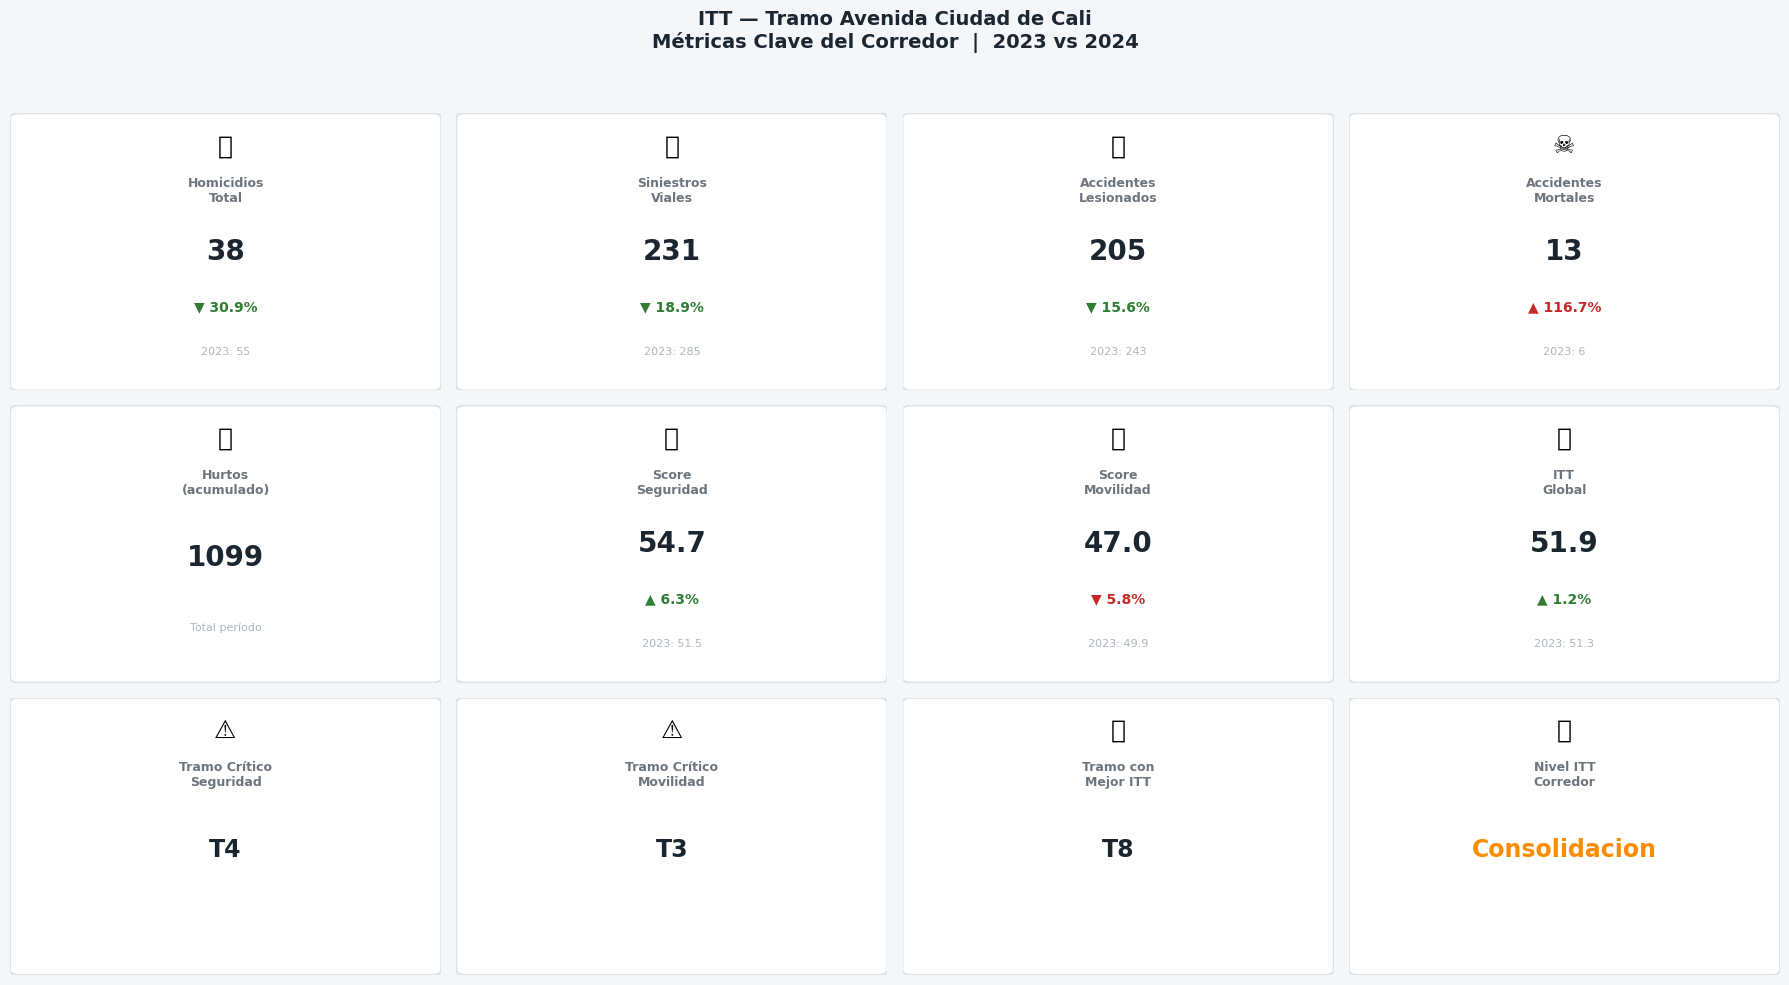

✅ Cards generados


In [12]:
def safe_pct(new, old):
    """Calcula variación porcentual, maneja división por cero"""
    if old == 0: return 0.0
    return (new - old) / old * 100

def arrow(pct, inv=True):
    """Flecha e interpretación: inv=True significa que bajar es mejor"""
    if abs(pct) < 1: return '→ Sin cambio', 'gray'
    if inv:
        return ('▼ ' + f'{abs(pct):.1f}%', '#2E7D32') if pct < 0 else ('▲ ' + f'{abs(pct):.1f}%', '#C62828')
    else:
        return ('▲ ' + f'{abs(pct):.1f}%', '#2E7D32') if pct > 0 else ('▼ ' + f'{abs(pct):.1f}%', '#C62828')

# Calcular métricas
d23 = base[base['año']==2023]
d24 = base[base['año']==2024]

m = {
    'hom_23': int(d23['homicidios'].sum()),
    'hom_24': int(d24['homicidios'].sum()),
    'sin_23': int(d23['siniestralidad'].sum()),
    'sin_24': int(d24['siniestralidad'].sum()),
    'les_23': int(d23['lesionados'].sum()),
    'les_24': int(d24['lesionados'].sum()),
    'mor_23': int(d23['mortales'].sum()),
    'mor_24': int(d24['mortales'].sum()),
    'hur_tot': int(d23['hurtos'].sum()),
    'itt_23': d23['ITT'].mean(),
    'itt_24': d24['ITT'].mean(),
    'seg_23': d23['score_seguridad'].mean(),
    'seg_24': d24['score_seguridad'].mean(),
    'mov_23': d23['score_movilidad'].mean(),
    'mov_24': d24['score_movilidad'].mean(),
    'tramo_crit_seg': d24.loc[d24['score_seguridad'].idxmin(),'tramo'],
    'tramo_crit_mov': d24.loc[d24['score_movilidad'].idxmin(),'tramo'],
    'tramo_mejor':    d24.loc[d24['ITT'].idxmax(),'tramo'],
}

fig = plt.figure(figsize=(18, 10), facecolor=BG)
fig.suptitle('ITT — Tramo Avenida Ciudad de Cali\nMétricas Clave del Corredor  |  2023 vs 2024',
             fontsize=14, fontweight='bold', color='#1B2631', y=0.98)

# Layout: 3 filas × 4 cols de cards
card_data = [
    # (título, valor_23, valor_24, icono, invertido)
    ('Homicidios\nTotal',    m['hom_23'], m['hom_24'],  '🔴', True),
    ('Siniestros\nViales',   m['sin_23'], m['sin_24'],  '🚗', True),
    ('Accidentes\nLesionados', m['les_23'], m['les_24'],'🏥', True),
    ('Accidentes\nMortales', m['mor_23'], m['mor_24'],  '☠️', True),
    ('Hurtos\n(acumulado)',  m['hur_tot'], None,         '💰', True),
    ('Score\nSeguridad',     m['seg_23'], m['seg_24'],  '🛡️', False),
    ('Score\nMovilidad',     m['mov_23'], m['mov_24'],  '🚦', False),
    ('ITT\nGlobal',          m['itt_23'], m['itt_24'],  '📊', False),
    ('Tramo Crítico\nSeguridad', None, f'T{m["tramo_crit_seg"]}', '⚠️', None),
    ('Tramo Crítico\nMovilidad', None, f'T{m["tramo_crit_mov"]}', '⚠️', None),
    ('Tramo con\nMejor ITT', None, f'T{m["tramo_mejor"]}', '🏆', None),
    ('Nivel ITT\nCorredor', None, clasificar(m['itt_24']), '📌', None),
]

nrows, ncols = 3, 4
for i, (titulo, v23, v24, icon, inv) in enumerate(card_data):
    ax = fig.add_subplot(nrows, ncols, i+1)
    ax.set_xlim(0,1); ax.set_ylim(0,1)
    ax.axis('off')
    ax.set_facecolor('white')

    # Borde card
    rect = mpatches.FancyBboxPatch((0.02,0.02), 0.96, 0.96,
        boxstyle='round,pad=0.02', linewidth=1.5,
        edgecolor='#DEE2E6', facecolor='white')
    ax.add_patch(rect)

    ax.text(0.5, 0.88, icon, ha='center', va='center', fontsize=18)
    ax.text(0.5, 0.72, titulo, ha='center', va='center',
            fontsize=9, color='#6C757D', fontweight='bold')

    if v23 is not None and v24 is not None and inv is not None:
        # Card comparativa
        pct = safe_pct(v24, v23)
        ar_txt, ar_col = arrow(pct, inv)
        if isinstance(v24, float):
            ax.text(0.5, 0.50, f'{v24:.1f}', ha='center', va='center',
                    fontsize=20, fontweight='bold', color='#1B2631')
        else:
            ax.text(0.5, 0.50, str(v24), ha='center', va='center',
                    fontsize=20, fontweight='bold', color='#1B2631')
        ax.text(0.5, 0.30, ar_txt, ha='center', va='center',
                fontsize=10, color=ar_col, fontweight='bold')
        ax.text(0.5, 0.14, f'2023: {v23:.1f}' if isinstance(v23,float) else f'2023: {v23}',
                ha='center', va='center', fontsize=8, color='#ADB5BD')
    elif v24 is not None and v23 is None:
        # Card informativa
        color = NIVEL_COLORS.get(v24, '#1B2631') if inv is None and titulo.startswith('Nivel') else '#1B2631'
        ax.text(0.5, 0.45, str(v24), ha='center', va='center',
                fontsize=17, fontweight='bold', color=color)
    elif v23 is not None and v24 is None:
        # Solo valor total
        ax.text(0.5, 0.45, str(v23), ha='center', va='center',
                fontsize=20, fontweight='bold', color='#1B2631')
        ax.text(0.5, 0.20, 'Total período', ha='center', va='center',
                fontsize=8, color='#ADB5BD')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('itt_cards.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print('✅ Cards generados')


## Celda 11 —  Evolución trimestral: Dimensión Seguridad


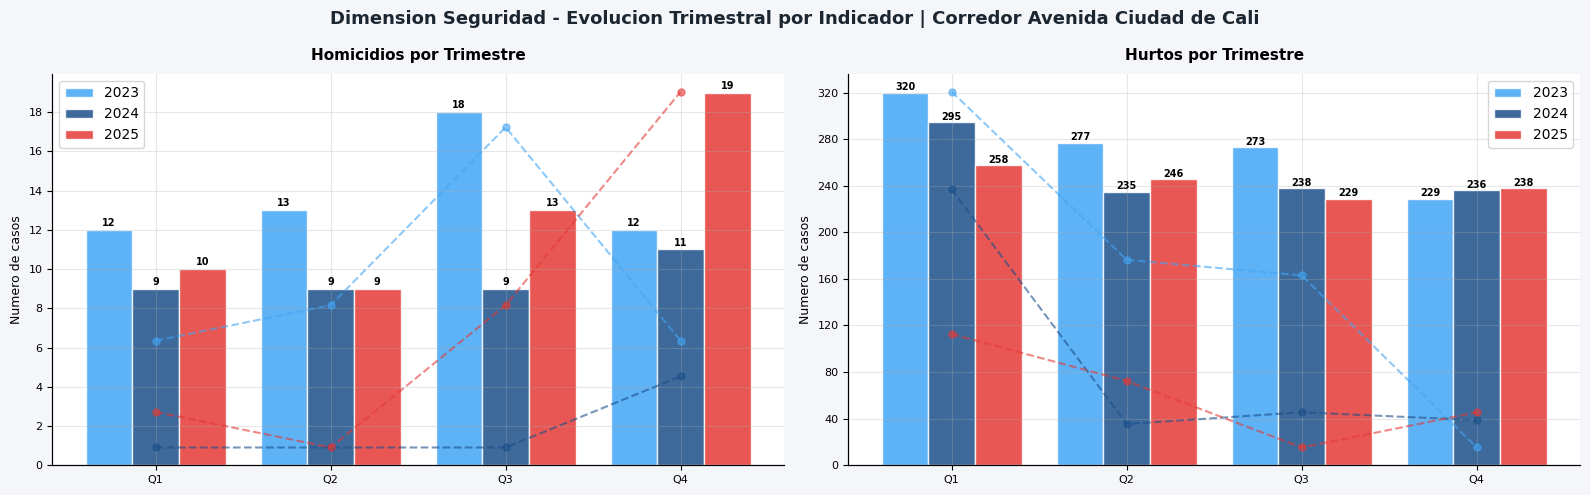

Homicidios  2023: 55
Homicidios  2024: 38  |  vs 2023: -30.9%
Homicidios  2025: 51  |  vs 2024: +34.2%
Hurtos      2023: 1099
Hurtos      2024: 1004  |  vs 2023: -8.6%
Hurtos      2025: 971  |  vs 2024: -3.3%


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5), facecolor=BG)
titulo = "Dimension Seguridad - Evolucion Trimestral por Indicador | Corredor Avenida Ciudad de Cali"
fig.suptitle(titulo, fontsize=13, fontweight="bold", color="#1B2631")

x  = np.arange(4)
n  = len(ANIOS)
w  = 0.8 / n
COLORES_HOM = ["#42A5F5", "#1B4F8A", "#E53935"]
COLORES_HUR = ["#42A5F5", "#1B4F8A", "#E53935"]

# ── Panel 1: Homicidios trimestrales ─────────────────────
ax1 = axes[0]
bars_hom = []
for idx, año in enumerate(ANIOS):
    vals = corr_trim[corr_trim["año"]==año]["homicidios"].values
    offset = (idx - n/2 + 0.5) * w
    b = ax1.bar(x + offset, vals, w, label=str(año),
                color=COLORES_HOM[idx % len(COLORES_HOM)], alpha=0.85, edgecolor="white")
    bars_hom.append((vals, COLORES_HOM[idx % len(COLORES_HOM)]))
    for bar in b:
        h = bar.get_height()
        if h > 0:
            ax1.text(bar.get_x()+bar.get_width()/2, h+0.1, str(int(h)),
                     ha="center", va="bottom", fontsize=7, fontweight="bold")

ax1_t = ax1.twinx()
for vals, col in bars_hom:
    ax1_t.plot(x, vals, "o--", color=col, alpha=0.6, linewidth=1.5, markersize=5)
ax1_t.set_yticks([])
ax1_t.spines["right"].set_visible(False)
ax1_t.spines["top"].set_visible(False)

ax1.set_title("Homicidios por Trimestre", fontweight="bold", pad=10)
ax1.set_xticks(x); ax1.set_xticklabels(["Q1","Q2","Q3","Q4"])
ax1.set_ylabel("Numero de casos")
ax1.yaxis.set_major_locator(plt.MaxNLocator(integer=True))
ax1.legend()

# ── Panel 2: Hurtos ───────────────────────────────────────
ax2 = axes[1]
if HURTOS_CON_FECHA:
    bars_hur = []
    for idx, año in enumerate(ANIOS):
        vals = corr_trim[corr_trim["año"]==año]["hurtos"].values
        offset = (idx - n/2 + 0.5) * w
        b = ax2.bar(x + offset, vals, w, label=str(año),
                    color=COLORES_HUR[idx % len(COLORES_HUR)], alpha=0.85, edgecolor="white")
        bars_hur.append((vals, COLORES_HUR[idx % len(COLORES_HUR)]))
        for bar in b:
            h = bar.get_height()
            if h > 0:
                ax2.text(bar.get_x()+bar.get_width()/2, h+0.1, str(int(h)),
                         ha="center", va="bottom", fontsize=7, fontweight="bold")
    ax2_t = ax2.twinx()
    for vals, col in bars_hur:
        ax2_t.plot(x, vals, "o--", color=col, alpha=0.6, linewidth=1.5, markersize=5)
    ax2_t.set_yticks([])
    ax2_t.spines["right"].set_visible(False)
    ax2_t.spines["top"].set_visible(False)
    ax2.set_title("Hurtos por Trimestre", fontweight="bold", pad=10)
    ax2.set_xticks(x); ax2.set_xticklabels(["Q1","Q2","Q3","Q4"])
    ax2.set_ylabel("Numero de casos")
    ax2.yaxis.set_major_locator(plt.MaxNLocator(integer=True))
    ax2.legend()
else:
    hur_t  = hur_total.sort_values("tramo")
    tr_lbl = [f"T{t}" for t in hur_t["tramo"]]
    bars_h = ax2.barh(tr_lbl, hur_t["hurtos"], color=COLORES_HUR[0], alpha=0.8, edgecolor="white")
    ax2.set_title("Hurtos Totales por Tramo (sin desagregacion temporal)", fontweight="bold", pad=8)
    ax2.set_xlabel("Numero de hurtos")
    ax2.invert_yaxis()
    for bar in bars_h:
        w_b = bar.get_width()
        ax2.text(w_b+2, bar.get_y()+bar.get_height()/2, str(int(w_b)),
                 va="center", ha="left", fontsize=9, fontweight="bold", color=COLORES_HUR[0])

plt.tight_layout()
plt.savefig("itt_seg_trimestral.png", dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()

# ── Resumen consola ───────────────────────────────────────
for i, año in enumerate(ANIOS):
    tot_hom = int(corr_trim[corr_trim["año"]==año]["homicidios"].sum())
    if i == 0: print(f"Homicidios  {año}: {tot_hom}")
    else:
        tot_ant = int(corr_trim[corr_trim["año"]==ANIOS[i-1]]["homicidios"].sum())
        print(f"Homicidios  {año}: {tot_hom}  |  vs {ANIOS[i-1]}: {safe_pct(tot_hom, tot_ant):+.1f}%")

if HURTOS_CON_FECHA:
    for i, año in enumerate(ANIOS):
        tot_hur = int(corr_trim[corr_trim["año"]==año]["hurtos"].sum())
        if i == 0: print(f"Hurtos      {año}: {tot_hur}")
        else:
            tot_ant = int(corr_trim[corr_trim["año"]==ANIOS[i-1]]["hurtos"].sum())
            print(f"Hurtos      {año}: {tot_hur}  |  vs {ANIOS[i-1]}: {safe_pct(tot_hur, tot_ant):+.1f}%")

## Celda 12 — Evolución trimestral: Dimensión Movilidad


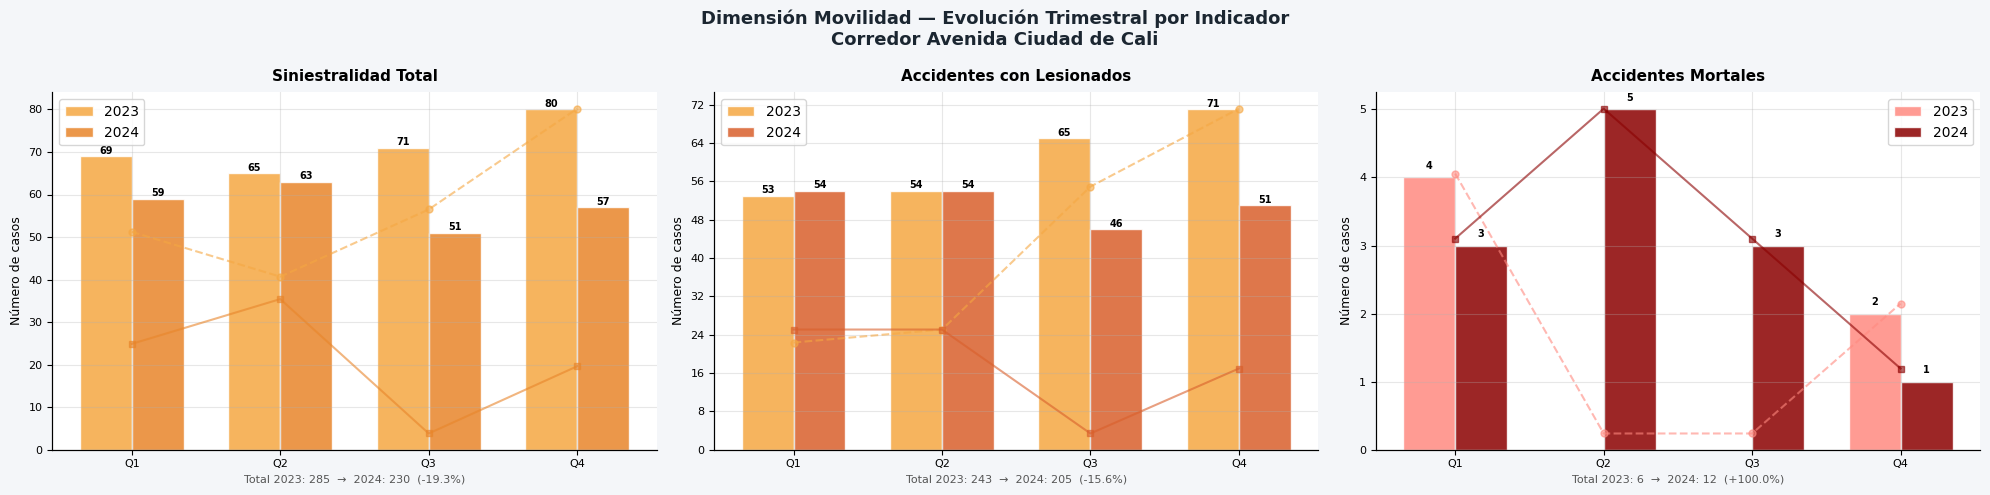

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5), facecolor=BG)
fig.suptitle('Dimensión Movilidad — Evolución Trimestral por Indicador\nCorredor Avenida Ciudad de Cali',
             fontsize=13, fontweight='bold', color='#1B2631')

x = np.arange(4)
w = 0.35
configs = [
    (axes[0], 'siniestralidad', 'Siniestralidad Total', C_SIN, C_MOV),
    (axes[1], 'lesionados',     'Accidentes con Lesionados', '#F5A742', '#D95F2B'),
    (axes[2], 'mortales',       'Accidentes Mortales', '#FF8A80', C_MOR),
]

for ax, col, titulo, c23, c24 in configs:
    v23 = corr_trim[corr_trim['año']==2023][col].values
    v24 = corr_trim[corr_trim['año']==2024][col].values

    b1 = ax.bar(x-w/2, v23, w, label='2023', color=c23, alpha=0.85, edgecolor='white')
    b2 = ax.bar(x+w/2, v24, w, label='2024', color=c24, alpha=0.85, edgecolor='white')

    # Línea tendencia
    ax_t = ax.twinx()
    ax_t.plot(x, v23, 'o--', color=c23, alpha=0.6, linewidth=1.5, markersize=5)
    ax_t.plot(x, v24, 's-',  color=c24, alpha=0.6, linewidth=1.5, markersize=5)
    ax_t.set_yticks([])
    ax_t.spines['right'].set_visible(False)
    ax_t.spines['top'].set_visible(False)

    ax.set_title(titulo, fontweight='bold', pad=8)
    ax.set_xticks(x); ax.set_xticklabels(['Q1','Q2','Q3','Q4'])
    ax.set_ylabel('Número de casos')
    ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))
    ax.legend()

    for bar in [*b1, *b2]:
        h = bar.get_height()
        if h > 0:
            ax.text(bar.get_x()+bar.get_width()/2, h+0.1, str(int(h)),
                    ha='center', va='bottom', fontsize=7, fontweight='bold')

    tot23, tot24 = int(sum(v23)), int(sum(v24))
    pct = safe_pct(tot24, tot23)
    ax.set_xlabel(f'Total 2023: {tot23}  →  2024: {tot24}  ({pct:+.1f}%)',
                  fontsize=8, color='#555')

plt.tight_layout()
plt.savefig('itt_mov_trimestral.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


## Celda 12B —  Evolución trimestral: Dimensión Cohesión Social


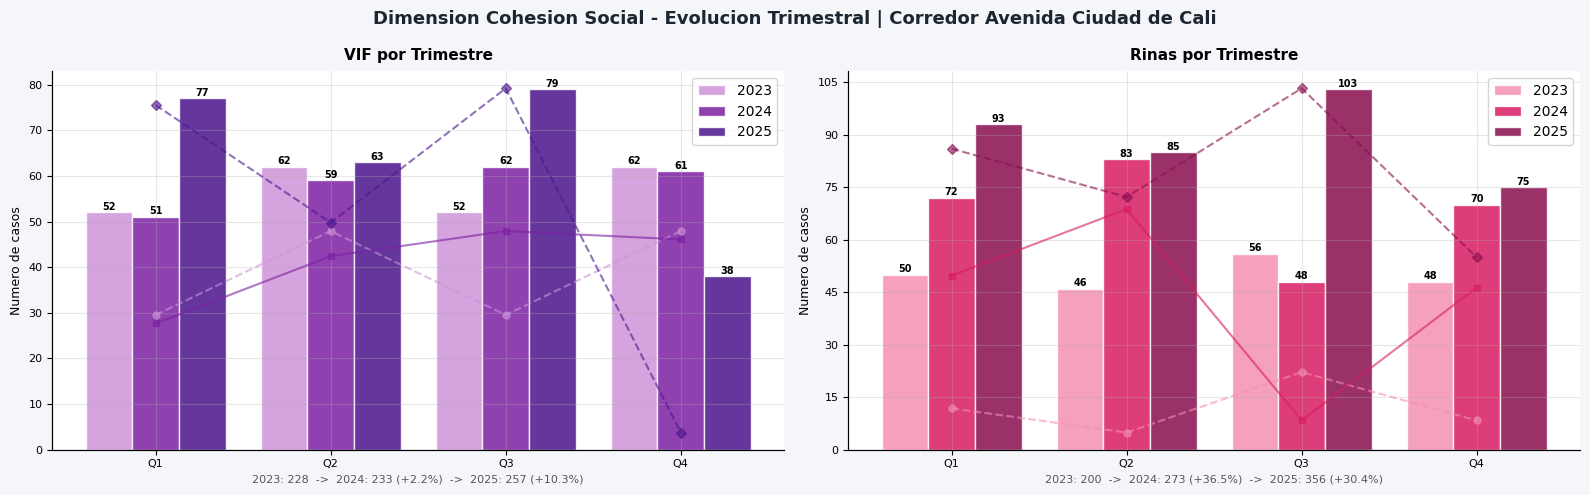

In [16]:
# Evolucion trimestral VIF y Rinas
fig, axes = plt.subplots(1, 2, figsize=(16, 5), facecolor=BG)
titulo = "Dimension Cohesion Social - Evolucion Trimestral | Corredor Avenida Ciudad de Cali"
fig.suptitle(titulo, fontsize=13, fontweight="bold", color="#1B2631")

x = np.arange(4)
n = len(ANIOS)
w = 0.8 / n
COLORES_VIF = ["#CE93D8","#7B1FA2","#4A148C"]
COLORES_RIN = ["#F48FB1","#D81B60","#880E4F"]

for ax, col, colores, titulo_p in [
    (axes[0], "vif",   COLORES_VIF, "VIF por Trimestre"),
    (axes[1], "rinas", COLORES_RIN, "Rinas por Trimestre"),
]:
    bars_list = []
    for idx, año in enumerate(ANIOS):
        vals   = corr_trim[corr_trim["año"]==año][col].values
        offset = (idx - n/2 + 0.5) * w
        b = ax.bar(x+offset, vals, w, label=str(año),
                   color=colores[idx%len(colores)], alpha=0.85, edgecolor="white")
        bars_list.append((vals, colores[idx%len(colores)]))
        for bar in b:
            h = bar.get_height()
            if h > 0:
                ax.text(bar.get_x()+bar.get_width()/2, h+0.1, str(int(h)),
                        ha="center", va="bottom", fontsize=7, fontweight="bold")
    ax_t = ax.twinx()
    for i,(vals,col_c) in enumerate(bars_list):
        ax_t.plot(x, vals, ["o--","s-","D--"][i%3], color=col_c, alpha=0.6, linewidth=1.5, markersize=5)
    ax_t.set_yticks([]); ax_t.spines["right"].set_visible(False); ax_t.spines["top"].set_visible(False)
    ax.set_title(titulo_p, fontweight="bold", pad=8)
    ax.set_xticks(x); ax.set_xticklabels(["Q1","Q2","Q3","Q4"])
    ax.set_ylabel("Numero de casos")
    ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))
    ax.legend()
    resumen = ""
    for i, año in enumerate(ANIOS):
        tot = int(corr_trim[corr_trim["año"]==año][col].sum())
        if i == 0: resumen += f"{año}: {tot}"
        else:
            tot_ant = int(corr_trim[corr_trim["año"]==ANIOS[i-1]][col].sum())
            resumen += f"  ->  {año}: {tot} ({safe_pct(tot,tot_ant):+.1f}%)"
    ax.set_xlabel(resumen, fontsize=8, color="#555")

plt.tight_layout()
plt.savefig("itt_cohesion_trimestral.png", dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()


## Celda 13 —  Heatmap Cohesión Social: VIF y Riñas por tramo


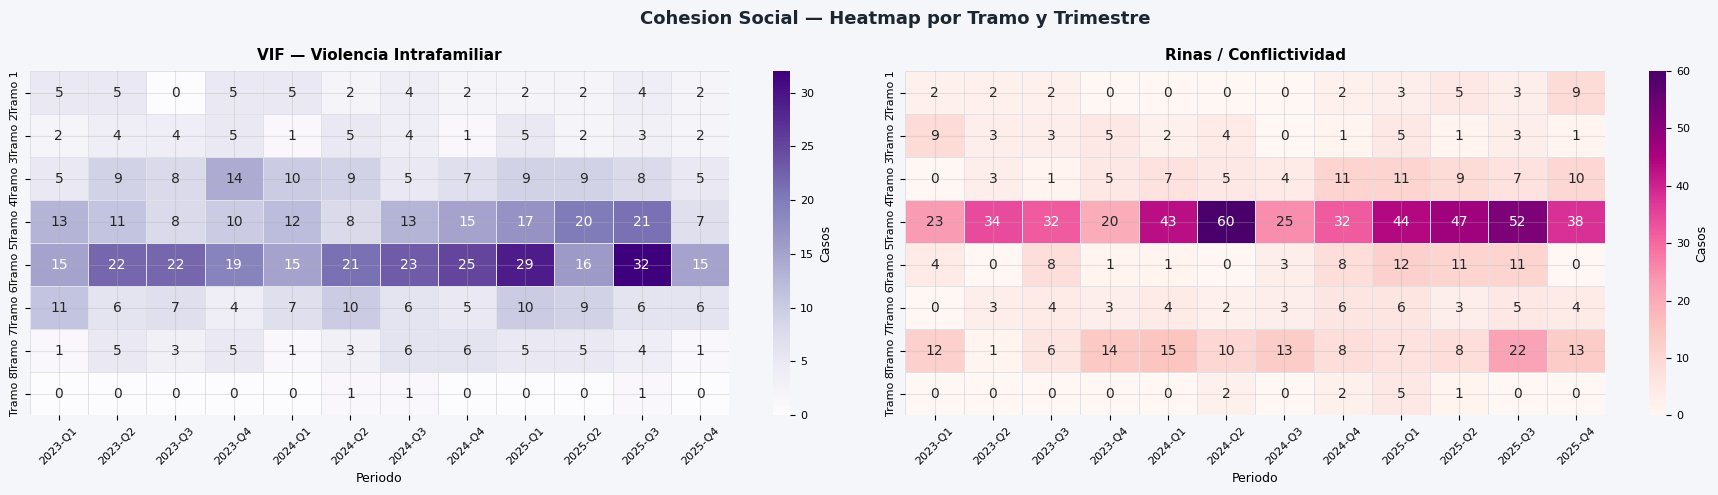

Heatmap Cohesion Social generado


In [17]:
# Heatmap VIF y Riñas por tramo x trimestre
fig, axes = plt.subplots(1, 2, figsize=(18, 5), facecolor=BG)
fig.suptitle("Cohesion Social — Heatmap por Tramo y Trimestre",
             fontsize=13, fontweight="bold", color="#1B2631")

for ax, col, titulo_h, cmap_h in [
    (axes[0], "vif",   "VIF — Violencia Intrafamiliar", "Purples"),
    (axes[1], "rinas", "Rinas / Conflictividad",        "RdPu"),
]:
    pivot = base_trim.groupby(["tramo","periodo"])[col].sum().unstack(fill_value=0)
    pivot.index = [f"Tramo {t}" for t in pivot.index]
    sns.heatmap(pivot, annot=True, fmt=".0f", cmap=cmap_h,
                linewidths=0.4, linecolor="#DEE2E6", ax=ax,
                cbar_kws={"label":"Casos"})
    ax.set_title(titulo_h, fontweight="bold", pad=8)
    ax.set_xlabel("Periodo"); ax.set_ylabel("")
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig("itt_heatmap_cohesion.png", dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()
print("Heatmap Cohesion Social generado")


## Celda 14 —  Scores de dimensión por tramo


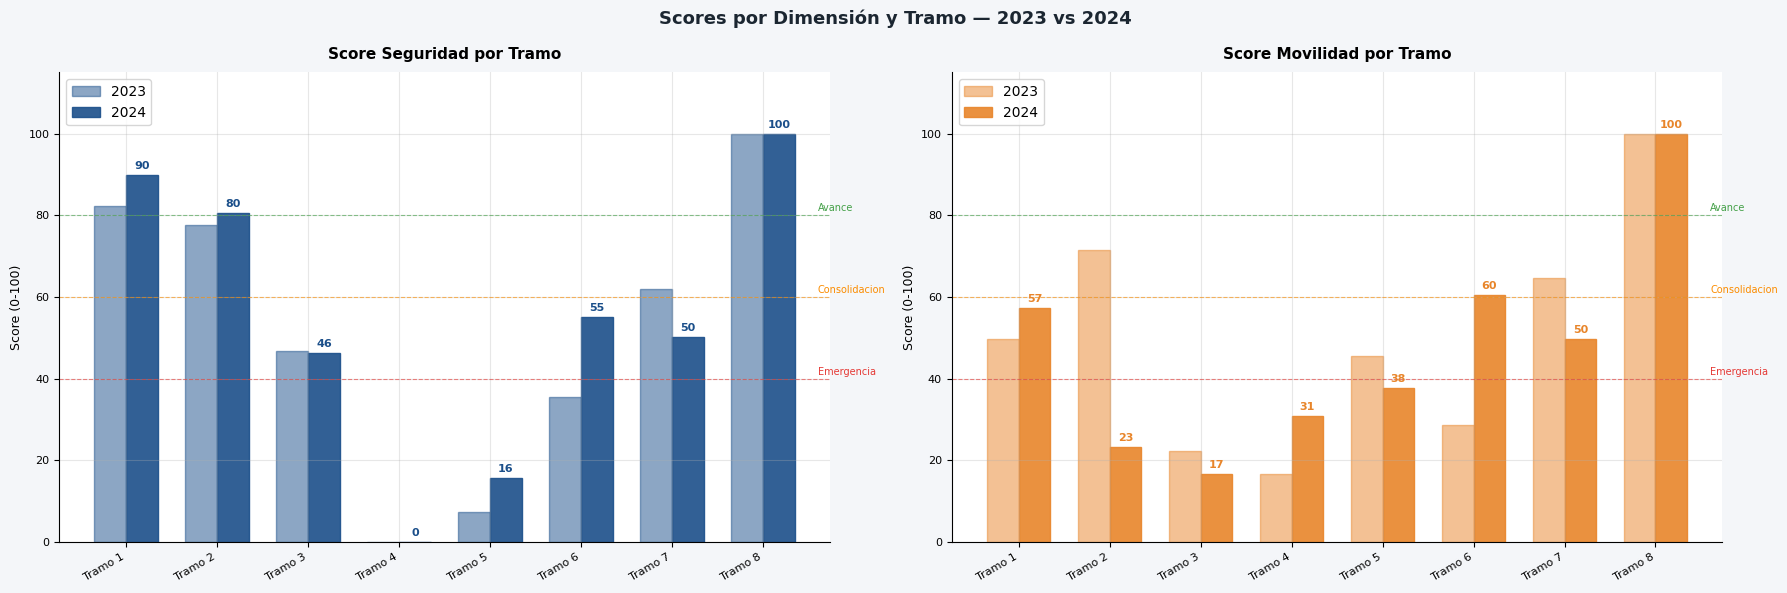

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6), facecolor=BG)
fig.suptitle('Scores por Dimensión y Tramo — 2023 vs 2024',
             fontsize=13, fontweight='bold', color='#1B2631')

for idx, (ax, dim, col, title) in enumerate([
    (axes[0], 'score_seguridad', C_SEG, 'Seguridad'),
    (axes[1], 'score_movilidad', C_MOV, 'Movilidad'),
]):
    d23 = base[base['año']==2023].sort_values('tramo')
    d24 = base[base['año']==2024].sort_values('tramo')
    tr_lbl = [f'Tramo {t}' for t in d23['tramo']]
    x_pos = np.arange(len(tr_lbl))
    w = 0.35

    b1 = ax.bar(x_pos-w/2, d23[dim], w, label='2023', color=col, alpha=0.5, edgecolor=col)
    b2 = ax.bar(x_pos+w/2, d24[dim], w, label='2024', color=col, alpha=0.9, edgecolor=col)

    # Línea de referencia niveles
    for nivel_y, nivel_lbl, nivel_col in [(40,'Emergencia','#E53935'),(60,'Consolidacion','#FB8C00'),(80,'Avance','#43A047')]:
        ax.axhline(nivel_y, linestyle='--', linewidth=0.8, color=nivel_col, alpha=0.6)
        ax.text(len(tr_lbl)-0.4, nivel_y+0.5, nivel_lbl, fontsize=7, color=nivel_col, va='bottom')

    ax.set_title(f'Score {title} por Tramo', fontweight='bold', pad=10)
    ax.set_xticks(x_pos); ax.set_xticklabels(tr_lbl, rotation=30, ha='right')
    ax.set_ylabel('Score (0-100)')
    ax.set_ylim(0, 115)
    ax.legend()

    # Anotaciones valor 2024
    for bar in b2:
        h = bar.get_height()
        ax.text(bar.get_x()+bar.get_width()/2, h+1, f'{h:.0f}',
                ha='center', va='bottom', fontsize=8, fontweight='bold', color=col)

plt.tight_layout()
plt.savefig('itt_scores_tramo.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


## Celda 15 —  Heatmap scores por indicador y tramo


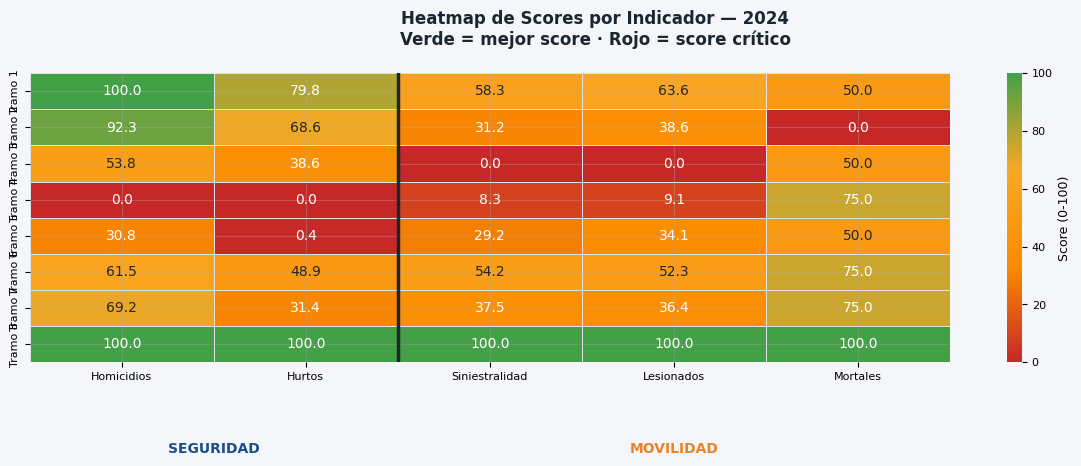

In [19]:
d24 = base[base['año']==2024].sort_values('tramo').set_index('tramo')

score_cols = ['score_homicidios','score_hurtos','score_siniestralidad','score_lesionados','score_mortales']
score_lbl  = ['Homicidios','Hurtos','Siniestralidad','Lesionados','Mortales']

hmap_data = d24[score_cols].copy()
hmap_data.columns = score_lbl
hmap_data.index = [f'Tramo {t}' for t in hmap_data.index]

fig, ax = plt.subplots(figsize=(12, 5), facecolor=BG)
fig.suptitle('Heatmap de Scores por Indicador — 2024\nVerde = mejor score · Rojo = score crítico',
             fontsize=12, fontweight='bold', color='#1B2631')

cmap = LinearSegmentedColormap.from_list('itt', ['#C62828','#FB8C00','#F9A825','#43A047'])
sns.heatmap(hmap_data, annot=True, fmt='.1f', cmap=cmap,
            vmin=0, vmax=100, linewidths=0.5, linecolor='#DEE2E6',
            ax=ax, cbar_kws={'label':'Score (0-100)'})

# Separador dimensiones
ax.axvline(x=2, color='#1B2631', linewidth=2.5, linestyle='-')
ax.text(1.0, -0.3, 'SEGURIDAD', ha='center', va='center',
        fontsize=10, fontweight='bold', color=C_SEG, transform=ax.get_xaxis_transform())
ax.text(3.5, -0.3, 'MOVILIDAD', ha='center', va='center',
        fontsize=10, fontweight='bold', color=C_MOV, transform=ax.get_xaxis_transform())

ax.set_xlabel('')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('itt_heatmap.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


## Celda 16 —  ITT Global por tramo


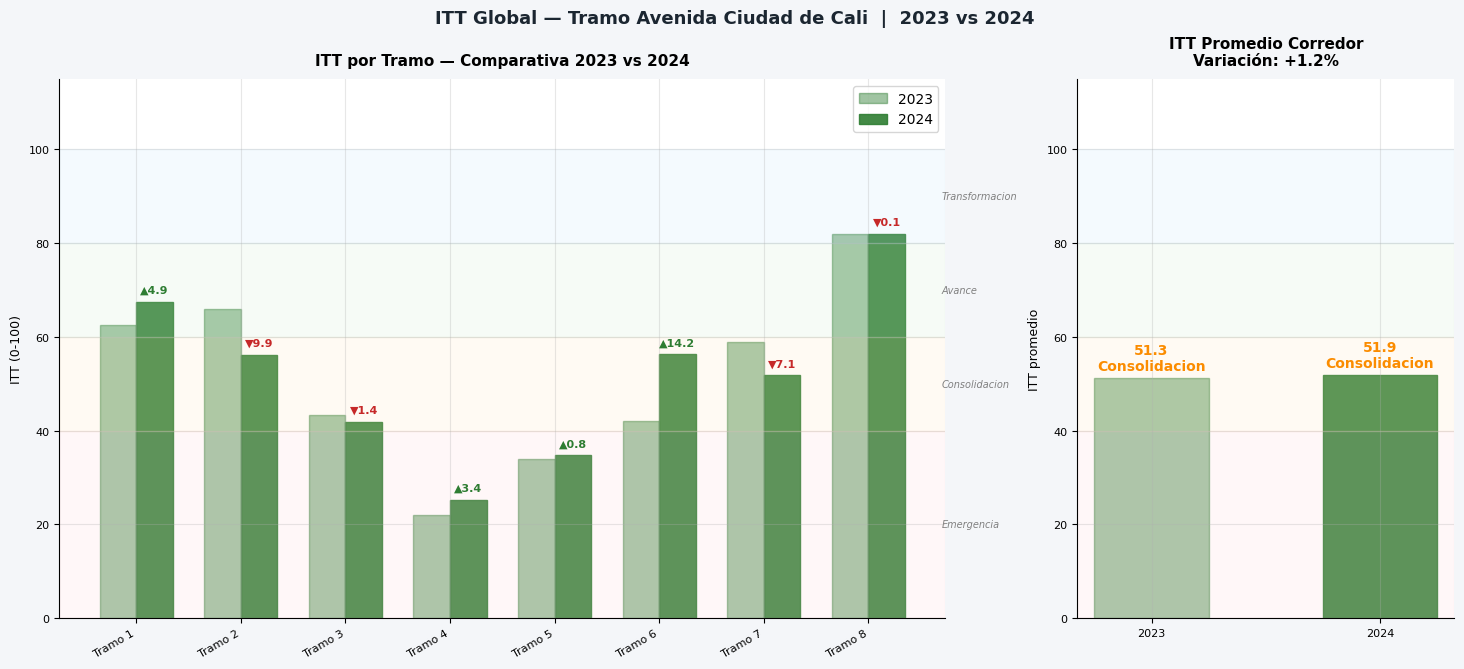

ITT Corredor — 2023: 51.3 (Consolidacion)  |  2024: 51.9 (Consolidacion)


In [20]:
fig = plt.figure(figsize=(18, 7), facecolor=BG)
fig.suptitle('ITT Global — Tramo Avenida Ciudad de Cali  |  2023 vs 2024',
             fontsize=13, fontweight='bold', color='#1B2631')

gs = gridspec.GridSpec(1, 3, figure=fig, wspace=0.35)
ax1 = fig.add_subplot(gs[0, :2])
ax2 = fig.add_subplot(gs[0, 2])

# ── Panel izquierdo: barras ITT 2023 vs 2024 ─────────────
d23s = base[base['año']==2023].sort_values('tramo')
d24s = base[base['año']==2024].sort_values('tramo')
tr_lbl = [f'Tramo {t}' for t in d23s['tramo']]
x_pos = np.arange(len(tr_lbl))
w = 0.35

b1 = ax1.bar(x_pos-w/2, d23s['ITT'], w, label='2023', color=C_ITT, alpha=0.45, edgecolor=C_ITT)
b2 = ax1.bar(x_pos+w/2, d24s['ITT'], w, label='2024', color=C_ITT, alpha=0.9, edgecolor=C_ITT)

# Bandas de nivel
band_configs = [
    (0,  40,  '#FFCDD2', 'Emergencia'),
    (40, 60,  '#FFE0B2', 'Consolidacion'),
    (60, 80,  '#C8E6C9', 'Avance'),
    (80, 100, '#BBDEFB', 'Transformacion'),
]
for y0, y1, color, lbl in band_configs:
    ax1.axhspan(y0, y1, alpha=0.15, color=color)
    ax1.text(len(tr_lbl)-0.3, (y0+y1)/2, lbl, va='center',
             fontsize=7, color='gray', style='italic')

# Flechas de mejora/empeoramiento
for i, (itt23, itt24) in enumerate(zip(d23s['ITT'], d24s['ITT'])):
    delta = itt24 - itt23
    col_delta = '#2E7D32' if delta >= 0 else '#C62828'
    simb = '▲' if delta >= 0 else '▼'
    ax1.text(x_pos[i]+w/2, itt24+1.5, f'{simb}{abs(delta):.1f}',
             ha='center', va='bottom', fontsize=8, color=col_delta, fontweight='bold')

ax1.set_title('ITT por Tramo — Comparativa 2023 vs 2024', fontweight='bold', pad=10)
ax1.set_xticks(x_pos); ax1.set_xticklabels(tr_lbl, rotation=30, ha='right')
ax1.set_ylabel('ITT (0-100)')
ax1.set_ylim(0, 115)
ax1.legend()

# ── Panel derecho: ITT promedio corredor ─────────────────
itt_prom_23 = d23s['ITT'].mean()
itt_prom_24 = d24s['ITT'].mean()
años_bar = [2023, 2024]
vals_bar = [itt_prom_23, itt_prom_24]
cols_bar = [C_ITT, C_ITT]
alphas   = [0.45, 0.9]

bars_g = ax2.bar(años_bar, vals_bar, color=cols_bar, alpha=0.8,
                 edgecolor=C_ITT, width=0.5)
for bar, val, alph in zip(bars_g, vals_bar, alphas):
    bar.set_alpha(alph)
    ax2.text(bar.get_x()+bar.get_width()/2, val+1,
             f'{val:.1f}\n{clasificar(val)}',
             ha='center', va='bottom', fontsize=10, fontweight='bold',
             color=NIVEL_COLORS.get(clasificar(val),'#1B2631'))

# Bandas
for y0, y1, color, lbl in band_configs:
    ax2.axhspan(y0, y1, alpha=0.15, color=color)

delta_corr = safe_pct(itt_prom_24, itt_prom_23)
ax2.set_title(f'ITT Promedio Corredor\nVariación: {delta_corr:+.1f}%',
              fontweight='bold', pad=10)
ax2.set_ylim(0, 115)
ax2.set_xticks(años_bar)
ax2.set_ylabel('ITT promedio')
ax2.set_facecolor('white')

plt.savefig('itt_global.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print(f'ITT Corredor — 2023: {itt_prom_23:.1f} ({clasificar(itt_prom_23)})  |  2024: {itt_prom_24:.1f} ({clasificar(itt_prom_24)})')


## Celda 17 —  Composición ITT por dimensión


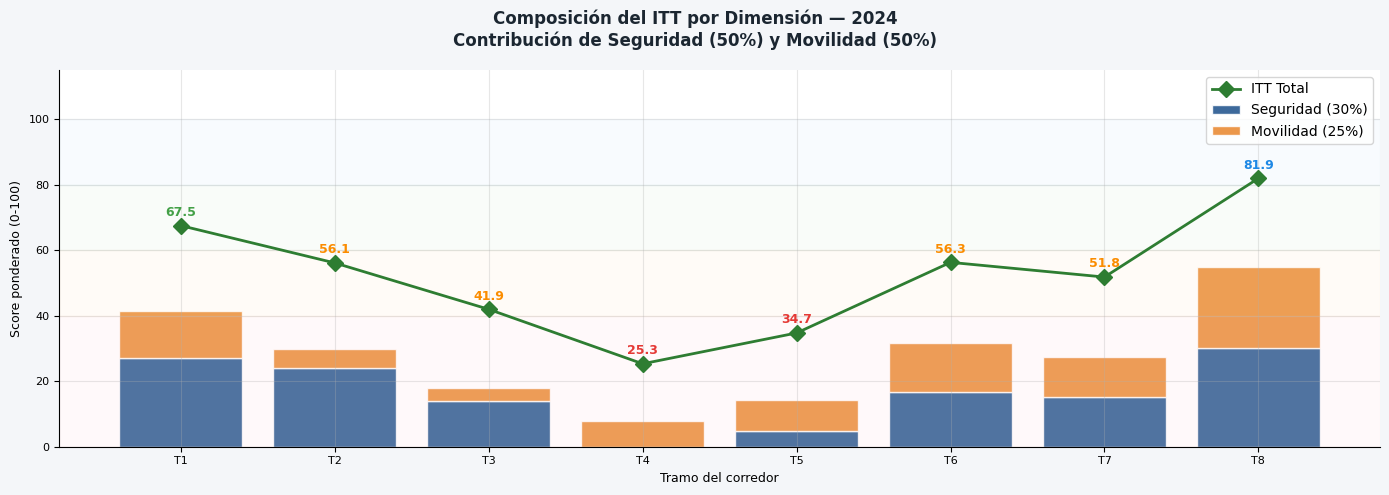

In [21]:
d24s = base[base['año']==2024].sort_values('tramo')
tr_lbl = [f'T{t}' for t in d24s['tramo']]
x_pos = np.arange(len(tr_lbl))

fig, ax = plt.subplots(figsize=(14, 5), facecolor=BG)
fig.suptitle('Composición del ITT por Dimensión — 2024\nContribución de Seguridad (50%) y Movilidad (50%)',
             fontsize=12, fontweight='bold', color='#1B2631')

contrib_seg = d24s['score_seguridad'] * PESOS['Seguridad']
contrib_mov = d24s['score_movilidad'] * PESOS['Movilidad']

ax.bar(x_pos, contrib_seg, label=f'Seguridad ({PESOS["Seguridad"]:.0%})',
       color=C_SEG, alpha=0.85, edgecolor='white')
ax.bar(x_pos, contrib_mov, bottom=contrib_seg,
       label=f'Movilidad ({PESOS["Movilidad"]:.0%})',
       color=C_MOV, alpha=0.85, edgecolor='white')

# Línea ITT total
ax.plot(x_pos, d24s['ITT'], 'D-', color=C_ITT, linewidth=2,
        markersize=8, label='ITT Total', zorder=5)

# Anotaciones ITT
for i, (itt, nivel) in enumerate(zip(d24s['ITT'], d24s['nivel'])):
    ax.text(x_pos[i], itt+2, f'{itt:.1f}', ha='center', va='bottom',
            fontsize=9, fontweight='bold',
            color=NIVEL_COLORS.get(nivel, C_ITT))

# Bandas
for y0, y1, color, lbl in [(0,40,'#FFCDD2','Emergencia'),(40,60,'#FFE0B2','Consolidacion'),
                             (60,80,'#C8E6C9','Avance'),(80,100,'#BBDEFB','Transformacion')]:
    ax.axhspan(y0, y1, alpha=0.1, color=color)

ax.set_xticks(x_pos); ax.set_xticklabels(tr_lbl)
ax.set_ylabel('Score ponderado (0-100)')
ax.set_ylim(0, 115)
ax.legend(loc='upper right')
ax.set_xlabel('Tramo del corredor')

plt.tight_layout()
plt.savefig('itt_composicion.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


## Celda 18 — Radar ITT Global: Anual · Semestral · Trimestral


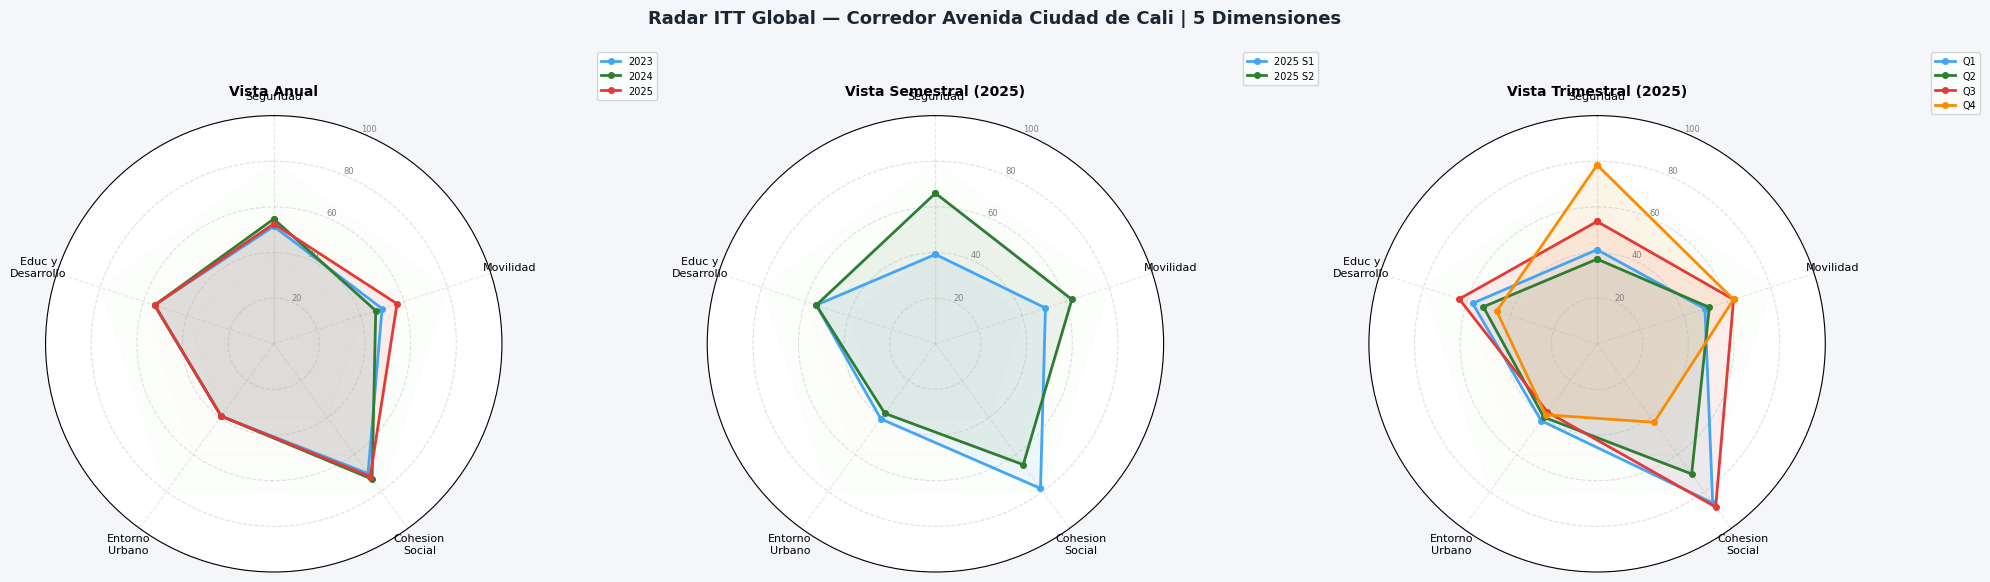

Radar ITT generado


In [22]:
# Radar ITT Global — 5 dimensiones: Anual | Semestral | Trimestral
DIMS_LBL  = ["Seguridad","Movilidad","Cohesion\nSocial","Entorno\nUrbano","Educ y\nDesarrollo"]
N_DIMS    = 5
angles    = [i/N_DIMS * 2 * np.pi for i in range(N_DIMS)] + [0]
COLORES_R = ["#42A5F5","#2E7D32","#E53935","#FB8C00","#7B1FA2","#00838F"]

def scores_periodo(df_b, mask):
    sub = df_b[mask]
    return [sub["score_seguridad"].mean(), sub["score_movilidad"].mean(),
            sub["score_cohesion"].mean(),  sub["score_entorno_u"].mean(),
            sub["score_educ_des"].mean()]

def draw_radar(ax, items, title):
    ax.set_theta_offset(np.pi/2); ax.set_theta_direction(-1)
    ax.set_xticks(angles[:-1]); ax.set_xticklabels(DIMS_LBL, fontsize=8)
    ax.set_ylim(0,100)
    ax.set_yticks([20,40,60,80,100])
    ax.set_yticklabels(["20","40","60","80","100"], fontsize=6, color="gray")
    ax.yaxis.grid(True, linestyle="--", alpha=0.4)
    ax.xaxis.grid(True, linestyle="--", alpha=0.3)
    for y,color in [(40,"#FFCDD2"),(60,"#FFE0B2"),(80,"#C8E6C9")]:
        ax.fill_between(angles, 0, y, alpha=0.04, color=color)
    for vals, lbl, col in items:
        vc = vals + [vals[0]]
        ax.plot(angles, vc, "o-", color=col, linewidth=2, markersize=4, label=lbl)
        ax.fill(angles, vc, alpha=0.08, color=col)
    ax.set_title(title, fontweight="bold", pad=15, fontsize=10)
    ax.legend(loc="upper right", bbox_to_anchor=(1.35,1.15), fontsize=7)

fig = plt.figure(figsize=(20, 6), facecolor=BG)
fig.suptitle("Radar ITT Global — Corredor Avenida Ciudad de Cali | 5 Dimensiones",
             fontsize=13, fontweight="bold", color="#1B2631")

# Panel 1: Anual
ax1 = fig.add_subplot(131, polar=True)
draw_radar(ax1,
    [(scores_periodo(base, base["año"]==a), str(a), COLORES_R[i]) for i,a in enumerate(ANIOS)],
    "Vista Anual")

# Panel 2: Semestral (año mas reciente)
ax2 = fig.add_subplot(132, polar=True)
año_r = ANIOS[-1]
items_sem = []
for sem_lbl, qs, col in [(f"{año_r} S1",[1,2],COLORES_R[0]),(f"{año_r} S2",[3,4],COLORES_R[1])]:
    mask_s = (base["año"]==año_r)
    s = scores_periodo(base, mask_s)
    # ajuste proporcional al semestre via base_trim
    sub_t = base_trim[(base_trim["año"]==año_r) & (base_trim["trimestre"].isin(qs))]
    tot_t = base_trim[base_trim["año"]==año_r]
    for di, dim_c in enumerate(["homicidios","siniestralidad","vif","hurtos","rinas"]):
        tot_a = tot_t[dim_c].sum()
        tot_s = sub_t[dim_c].sum() if dim_c in sub_t.columns else 0
        if tot_a > 0: s[di] = min(s[di] * (tot_s*2)/tot_a, 100)
    items_sem.append((s, sem_lbl, col))
draw_radar(ax2, items_sem, f"Vista Semestral ({año_r})")

# Panel 3: Trimestral (año mas reciente)
ax3 = fig.add_subplot(133, polar=True)
items_trim = []
for i, q in enumerate([1,2,3,4]):
    mask_a = (base["año"]==año_r)
    s = scores_periodo(base, mask_a)
    sub_t = base_trim[(base_trim["año"]==año_r) & (base_trim["trimestre"]==q)]
    tot_t = base_trim[base_trim["año"]==año_r]
    for di, dim_c in enumerate(["homicidios","siniestralidad","vif","hurtos","rinas"]):
        tot_a = tot_t[dim_c].sum()
        tot_q = sub_t[dim_c].sum() if dim_c in sub_t.columns else 0
        if tot_a > 0: s[di] = min(s[di] * (tot_q*4)/tot_a, 100)
    items_trim.append((s, f"Q{q}", COLORES_R[i]))
draw_radar(ax3, items_trim, f"Vista Trimestral ({año_r})")

plt.tight_layout()
plt.savefig("itt_radar.png", dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()
print("Radar ITT generado")


## Celda 19 —  Exportar resultados a Excel


In [23]:
EXPORT_PATH = "ITT_Avenida_Ciudad_de_Cali.xlsx"

with pd.ExcelWriter(EXPORT_PATH, engine="openpyxl") as writer:

    cols_exp = ["tramo","año","homicidios","hurtos","siniestralidad","lesionados","mortales","vif","rinas",
                "score_homicidios","score_hurtos","score_siniestralidad","score_lesionados",
                "score_mortales","score_vif","score_rinas",
                "score_seguridad","score_movilidad","score_cohesion",
                "score_entorno_u","score_educ_des","ITT","nivel"]
    base[cols_exp].round(2).to_excel(writer, sheet_name="ITT_por_Tramo", index=False)

    resumen = base.groupby("año").agg(
        homicidios_tot  =("homicidios",     "sum"),
        hurtos_tot      =("hurtos",          "sum"),
        siniestralidad  =("siniestralidad",  "sum"),
        lesionados_tot  =("lesionados",      "sum"),
        mortales_tot    =("mortales",        "sum"),
        vif_tot         =("vif",             "sum"),
        rinas_tot       =("rinas",           "sum"),
        score_seg       =("score_seguridad", "mean"),
        score_mov       =("score_movilidad", "mean"),
        score_coh       =("score_cohesion",  "mean"),
        score_entU      =("score_entorno_u", "mean"),
        score_eyd       =("score_educ_des",  "mean"),
        ITT_prom        =("ITT",             "mean"),
    ).round(2).reset_index()
    resumen.to_excel(writer, sheet_name="Resumen_Corredor", index=False)

    corr_trim.to_excel(writer, sheet_name="Series_Trimestrales", index=False)
    base_trim.to_excel(writer, sheet_name="Trim_por_Tramo", index=False)

    met = pd.DataFrame({"Elemento":[
        "Indice","Zona","Tramos","Periodo","Peso Seguridad","Peso Movilidad",
        "Peso Entorno Urbano","Peso Educ y Des","Peso Cohesion Social",
        "Indicadores Seguridad","Indicadores Movilidad","Indicadores Cohesion",
        "Entorno Urbano","Educ y Desarrollo","Normalizacion","ITT Global",
        "Nivel 1","Nivel 2","Nivel 3","Nivel 4"],
    "Descripcion":[
        "Indice de Transformacion Territorial (ITT)",
        "Tramo Avenida Ciudad de Cali",
        "8 poligonos buffer 100m sobre el eje vial",
        f"{ANIOS[0]}-{ANIOS[-1]}",
        f"{PESOS['Seguridad']:.0%}",f"{PESOS['Movilidad']:.0%}",
        f"{PESOS['EntornoU']:.0%} — ref Pulmon: {REF_ENTORNO_U}",
        f"{PESOS['EducDes']:.0%} — ref Pulmon: {REF_EDUC_DES}",
        f"{PESOS['Cohesion']:.0%}",
        "Homicidios + Hurtos (promedio simple)",
        "Siniestralidad + Lesionados + Mortales (promedio simple)",
        "VIF + Rinas (promedio simple)",
        f"Score fijo = {REF_ENTORNO_U} — provisional",
        f"Score fijo = {REF_EDUC_DES} — provisional",
        "Min-Max Inversa: Score = 100 - clamp((X-Xmin)/(Xmax-Xmin)*100,0,100)",
        "ITT = 0.30*Seg + 0.25*Mov + 0.20*EntU + 0.13*EyD + 0.12*Coh",
        "0-40 Emergencia","40-60 Consolidacion","60-80 Avance","80-100 Transformacion"]
    })
    met.to_excel(writer, sheet_name="Metodologia", index=False)

print(f"Exportado: {EXPORT_PATH}")
print("Hojas: ITT_por_Tramo | Resumen_Corredor | Series_Trimestrales | Trim_por_Tramo | Metodologia")


Exportado: ITT_Avenida_Ciudad_de_Cali.xlsx
Hojas: ITT_por_Tramo | Resumen_Corredor | Series_Trimestrales | Trim_por_Tramo | Metodologia
